# Cost saving opportunity for HCP

This jupyter notebook uses the following HCE table to get CPU utilization and AWS cost dataset:
* uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
* uip_iceberg.infra_analytics.hyperforce_aws_cost_allocated_view

Please read [this decision record](https://salesforce.quip.com/9u7CATaZNDz8) to understand how to calculate the utilization and cost.


If P95 CPU Utilization < 35%:

$$
  Saving Opportunity = \left(HCE Pod Cost ($) * 0.5\right) \times \left( 1-\frac{P95 CPU Utilization}{35} \right)
$$



## Initialization

In [126]:
%reload_ext autoreload
%autoreload 2

import os
import sys
module_path = os.path.abspath(os.path.join('../'))
sys.path.insert(0, module_path)

from huron.pod import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging
from datetime import datetime, timedelta
from collections import Counter

# If you want to print out SQL Query, set log level to logging.INFO.
logging.getLogger().setLevel(logging.INFO)

## Connect to UIP

### Option 1: UIP Notebook (Recommended)

Create Notebook by following [User Guide - UIP Notebook 2.0](https://confluence.internal.salesforce.com/display/UIP/User+Guide+-+UIP+Notebook+2.0#UserGuideUIPNotebook2.0-Prerequisites).

### Option 2: Local environment

1. Download [cacert.pem](https://git.soma.salesforce.com/Infrastructure-Security/puppet_pki_agent/blob/master/files/prod_ca/cacerts.pem) and save it as `.cacert.pem`
2. Copy the trino access code from [Salesforce trino authenticator](https://bdmpresto-access-server.sfproxy.uip.aws-esvc1-useast2.aws.sfdc.cl/)
3. Update the [.secrets.json](./.secrets.json) file

```json
{
    "username": "your_user_name",
    "access_code": "trino_access_code"
}
```

In [127]:
conn = None

try:
    from huron import connect_huron
    conn = connect_huron()
except:
    from uip_client.trino import TrinoConnection

    conn = TrinoConnection(
        catalog='huron-metrics',
        schema='metrics_hourly'
    )

INFO:root:Using Certificate Authentication...


## 2. Configure environment

By default, this script queries the metrics for `stage`, `esvc`, and `prod` environments. If you want to change the environment, please edit `ENV_TYPE` below.

In [128]:
ENV_TYPE = ['dev', 'test', 'perf','prod', 'stage', 'esvc']

TIMERANGE_FROM = '2025-05-01 00:00:00'
TIMERANGE_TO = '2025-05-31 00:00:00'

# Configure maximum rows for displaying dataframes
pd.options.display.max_rows = 100
# Configure maximum cols for displaying dataframes
pd.options.display.max_columns = 50
pd.options.display.float_format = '{:.3f}'.format

NAMESPACES = ["sam-system", "kube-system"]

# Set default custom filter. filter only sam cluster.
CUSTOM_FILTERS = "k8s_cluster like 'sam-%'"
# e.g. filter out coredns pod
#CUSTOM_FILTERS = "k8s_cluster like 'sam-%' AND k8s_pod_name like 'coredns%'"

In [129]:
# The following template gets the maximum request cpu and memory from kube-stat-metric
SQL_RESOURCE_TEMPLATE = """
with dedupe as (
  SELECT
      _time,
      scope,
      k8s_cluster,
      k8s_namespace,
      k8s_pod_name,
      k8s_container_name,
      element_at(tags,'resource') AS metric_type,
      MAX(max_value) AS value
  FROM huron_iceberg.metrics.metrics_hourly
  WHERE
    scope like '%(scope)s'
    AND metric = 'kube_pod_container_resource_requests'
    AND element_at(tags, 'resource') IN ('cpu', 'memory')
    AND element_at(tags, 'environment_type') in (%(envs)s)
    AND _time between TIMESTAMP '%(timerange_from)s' and TIMESTAMP '%(timerange_to)s'
    %(filters)s
  GROUP BY
      1,2,3,4,5,6,7
), sum_agg as (
  SELECT
      _time,
      scope, 
      k8s_cluster,
      k8s_namespace,
      k8s_pod_name,
    SUM(CASE
         WHEN metric_type = 'cpu'
         THEN value
         ELSE NULL
    END) as pod_request_cpu,
    SUM(CASE
         WHEN metric_type = 'memory'
         THEN value
         ELSE NULL
    END) as pod_request_mem
    FROM dedupe
  GROUP BY 1,2,3,4,5
)
SELECT
  format_datetime(_time, 'yyyyMMdd') as date_key,
  scope, 
  k8s_cluster,
  k8s_namespace,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  MAX(ROUND(pod_request_cpu, 5)) as request_cpu,
  MAX(pod_request_mem) as request_memory
FROM sum_agg
GROUP BY 1,2,3,4,5
ORDER BY date_key, scope, k8s_cluster, k8s_pod_name asc

"""

df_resource_spec = get_pod_with_resource_quota(conn, SQL_RESOURCE_TEMPLATE, TIMERANGE_FROM, TIMERANGE_TO, ENV_TYPE, HOURLY_METRIC_TABLE, NAMESPACES, CUSTOM_FILTERS)
df_resource_spec['resource_type'] = df_resource_spec.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[0], axis=1)
df_resource_spec['resource_name'] = df_resource_spec.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[1], axis=1)
df_resource_spec['deployment_name'] = df_resource_spec.apply(extract_deployment, axis=1)
df_resource_spec

INFO:root:
with dedupe as (
  SELECT
      _time,
      scope,
      k8s_cluster,
      k8s_namespace,
      k8s_pod_name,
      k8s_container_name,
      element_at(tags,'resource') AS metric_type,
      MAX(max_value) AS value
  FROM huron_iceberg.metrics.metrics_hourly
  WHERE
    scope like 'kube-state-metrics.aws.%'
    AND metric = 'kube_pod_container_resource_requests'
    AND element_at(tags, 'resource') IN ('cpu', 'memory')
    AND element_at(tags, 'environment_type') in ('dev', 'test', 'perf', 'prod', 'stage', 'esvc')
    AND _time between TIMESTAMP '2025-05-01 00:00:00' and TIMESTAMP '2025-05-31 00:00:00'
    AND k8s_namespace in ('sam-system', 'kube-system') AND k8s_cluster like 'sam-%'
  GROUP BY
      1,2,3,4,5,6,7
), sum_agg as (
  SELECT
      _time,
      scope, 
      k8s_cluster,
      k8s_namespace,
      k8s_pod_name,
    SUM(CASE
         WHEN metric_type = 'cpu'
         THEN value
         ELSE NULL
    END) as pod_request_cpu,
    SUM(CASE
         WHEN metric_

,date_key,scope,k8s_cluster,k8s_namespace,pod_group,k8s_pod_name,request_cpu,request_memory,resource_type,resource_name,deployment_name
0,20250501,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,aws-load-balancer-controller-7585cf8fd4,aws-load-balancer-controller-7585cf8fd4-ls6bk,0.100,1073741824.000,replicaset,aws-load-balancer-controller-7585cf8fd4,aws-load-balancer-controller
1,20250501,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,aws-node,aws-node-87ckq,0.025,67108864.000,daemonset,aws-node,aws-node
2,20250501,aws.aws-dev2-uswest2.apiq,sam-processing1,sam-system,cloudwatch-logexport-598816239137,cloudwatch-logexport-598816239137-0,0.220,786432000.000,statefulset,cloudwatch-logexport,cloudwatch-logexport
3,20250501,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,coredns-8cd545679,coredns-8cd545679-6s4bz,0.100,2147483648.000,replicaset,coredns-8cd545679,coredns
4,20250501,aws.aws-dev2-uswest2.apiq,sam-processing1,sam-system,dataplane-test-ds,dataplane-test-ds-px9qz,0.080,492830720.000,daemonset,dataplane-test-ds,dataplane-test-ds
...,...,...,...,...,...,...,...,...,...,...,...
833409,20250531,aws.test1-uswest2.unified-engagement,sam-processing1,kube-system,snapshot-controller-545548484d,snapshot-controller-545548484d-tmbw5,0.200,536870912.000,replicaset,snapshot-controller-545548484d,snapshot-controller
833410,20250531,aws.test1-uswest2.unified-engagement,sam-processing1,kube-system,snapshot-validation-6cd44f5dc5,snapshot-validation-6cd44f5dc5-pbmqs,0.200,536870912.000,replicaset,snapshot-validation-6cd44f5dc5,snapshot-validation
833411,20250531,aws.test1-uswest2.unified-engagement,sam-processing1,kube-system,vertical-pod-autoscaler-admission-controller-6...,vertical-pod-autoscaler-admission-controller-6...,0.250,268435456.000,replicaset,vertical-pod-autoscaler-admission-controller-6...,vertical-pod-autoscaler-admission-controller
833412,20250531,aws.test1-uswest2.unified-engagement,sam-processing1,kube-system,vertical-pod-autoscaler-recommender-795c7fc4cf,vertical-pod-autoscaler-recommender-795c7fc4cf...,0.100,268435456.000,replicaset,vertical-pod-autoscaler-recommender-795c7fc4cf,vertical-pod-autoscaler-recommender


In [130]:
# grouping by cluster
df_resource_quota_per_deploy = df_resource_spec[['date_key','scope','k8s_cluster','k8s_namespace','deployment_name', 'request_cpu', 'request_memory']].groupby(by=['date_key','scope','k8s_cluster','k8s_namespace','deployment_name', 'request_cpu', 'request_memory']).any().reset_index()
df_resource_quota_per_deploy['date_key'] = pd.to_numeric(df_resource_quota_per_deploy['date_key'])
df_resource_quota_per_deploy

,date_key,scope,k8s_cluster,k8s_namespace,deployment_name,request_cpu,request_memory
0,20250501,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,aws-load-balancer-controller,0.100,1073741824.000
1,20250501,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,aws-node,0.025,67108864.000
2,20250501,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,coredns,0.100,2147483648.000
3,20250501,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,ebs-csi-controller,0.700,1879048192.000
4,20250501,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,ebs-csi-node,0.300,805306368.000
...,...,...,...,...,...,...,...
782836,20250531,aws.test1-uswest2.unified-engagement,sam-processing1,sam-system,fkp-watchdog,0.570,3646947328.000
782837,20250531,aws.test1-uswest2.unified-engagement,sam-processing1,sam-system,host-path-permission-setter,0.001,10485760.000
782838,20250531,aws.test1-uswest2.unified-engagement,sam-processing1,sam-system,kube-hpa-generator,0.570,1474297856.000
782839,20250531,aws.test1-uswest2.unified-engagement,sam-processing1,sam-system,orphaned-volumes-pruner,0.250,792723456.000


In [131]:
# Calculate 
sql_cpu_util = """
WITH util_data AS (
  SELECT * FROM uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
  WHERE
    date_key between %(timerange_from)s and %(timerange_to)s
    AND level = 'pod'
    AND metric_name = 'cpu_req_util'
    AND aws_service = 'EC2 - Compute'
    AND k8s_pod_name is not NULL
    AND environment_type IN (%(envs)s)
    %(filters)s
)
SELECT
  date_key,
  concat('aws.', falcon_instance, '.', functional_domain) as scope,
  functional_domain,
  falcon_instance,
  environment_type,
  k8s_namespace,
  k8s_cluster,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  APPROX_PERCENTILE(util, value_count, 0.99) as p99_cpu,
  APPROX_PERCENTILE(util, value_count, 0.95) as p95_cpu
FROM util_data, UNNEST(value_counts)  AS ckv (util, value_count)
GROUP BY 1,2,3,4,5,6,7,8
ORDER BY date_key asc
"""

df_hce_cpu_util = query_aws_pod_unit_cost(conn, sql_cpu_util, TIMERANGE_FROM, TIMERANGE_TO, ENV_TYPE, NAMESPACES, CUSTOM_FILTERS)
df_hce_cpu_util['resource_type'] = df_hce_cpu_util.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[0], axis=1)
df_hce_cpu_util['resource_name'] = df_hce_cpu_util.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[1], axis=1)
df_hce_cpu_util['deployment_name'] = df_hce_cpu_util.apply(extract_deployment, axis=1)
df_hce_cpu_util.drop('k8s_pod_name', axis=1, inplace=True)
df_hce_cpu_util

INFO:root:
WITH util_data AS (
  SELECT * FROM uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
  WHERE
    date_key between 20250501 and 20250531
    AND level = 'pod'
    AND metric_name = 'cpu_req_util'
    AND aws_service = 'EC2 - Compute'
    AND k8s_pod_name is not NULL
    AND environment_type IN ('dev', 'test', 'perf', 'prod', 'stage', 'esvc')
    AND k8s_namespace in ('sam-system', 'kube-system') AND k8s_cluster like 'sam-%'
)
SELECT
  date_key,
  concat('aws.', falcon_instance, '.', functional_domain) as scope,
  functional_domain,
  falcon_instance,
  environment_type,
  k8s_namespace,
  k8s_cluster,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  APPROX_PERCENTILE(util, value_count, 0.99) as p99_cpu,
  APPROX_PERCENTILE(util, value_count, 0.95) as p95_cpu
FROM util_data, UNNEST(value_counts)  AS ckv (util, value_count)
GROUP BY 1,2,3,4,5,6,7,8
ORDER BY date_key asc



,date_key,scope,functional_domain,falcon_instance,environment_type,k8s_namespace,k8s_cluster,pod_group,p99_cpu,p95_cpu,resource_type,resource_name,deployment_name
0,20250501,aws.aws-prod16-eunorth1.core1,core1,aws-prod16-eunorth1,prod,kube-system,sam-restricted1,coredns-85946b8bcf,1.000,1.000,replicaset,coredns-85946b8bcf,coredns
1,20250501,aws.aws-prod14-apnortheast2.security,security,aws-prod14-apnortheast2,prod,kube-system,sam-mgmt-truth1,external-dns-86bd754454,1.000,1.000,replicaset,external-dns-86bd754454,external-dns
2,20250501,aws.aws-prod5-uswest2.core2,core2,aws-prod5-uswest2,prod,kube-system,sam-restricted11,ebs-csi-controller-6cd78d767f,1.000,1.000,replicaset,ebs-csi-controller-6cd78d767f,ebs-csi-controller
3,20250501,aws.aws-prod21-useast2.ecom1,ecom1,aws-prod21-useast2,prod,kube-system,sam-restricted1,ebs-csi-node,0.000,0.000,daemonset,ebs-csi-node,ebs-csi-node
4,20250501,aws.test1-uswest2.industries,industries,test1-uswest2,test,kube-system,sam-processing1,cluster-autoscaler-7cc8cbb9b6,6.856,6.182,replicaset,cluster-autoscaler-7cc8cbb9b6,cluster-autoscaler
...,...,...,...,...,...,...,...,...,...,...,...,...,...
757682,20250531,aws.aws-prod19-eusouth1.core1,core1,aws-prod19-eusouth1,prod,kube-system,sam-restricted4,coredns-5b97458c94,0.000,0.000,replicaset,coredns-5b97458c94,coredns
757683,20250531,aws.aws-esvc1-useast2.controltelemetry,controltelemetry,aws-esvc1-useast2,esvc,kube-system,sam-processing1,external-dns-647698797b,2.989,2.258,replicaset,external-dns-647698797b,external-dns
757684,20250531,aws.test1-uswest2.core3,core3,test1-uswest2,test,sam-system,sam-restricted1,host-path-permission-setter,17.000,15.000,daemonset,host-path-permission-setter,host-path-permission-setter
757685,20250531,aws.aws-prod5-uswest2.edge,edge,aws-prod5-uswest2,prod,kube-system,sam-processing1,cluster-autoscaler-6bd848655f,4.976,4.258,replicaset,cluster-autoscaler-6bd848655f,cluster-autoscaler


In [132]:
# Calculate 
sql_mem_util = """
WITH util_data AS (
  SELECT * FROM uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
  WHERE
    date_key between %(timerange_from)s and %(timerange_to)s
    AND level = 'pod'
    AND metric_name = 'memory_req_util'
    AND aws_service = 'EC2 - Compute'
    AND k8s_pod_name is not NULL
    AND environment_type IN (%(envs)s)
    %(filters)s
)
SELECT
  date_key,
  concat('aws.', falcon_instance, '.', functional_domain) as scope,
  functional_domain,
  falcon_instance,
  environment_type,
  k8s_namespace,
  k8s_cluster,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  APPROX_PERCENTILE(util, value_count, 0.99) as p99_mem,
  APPROX_PERCENTILE(util, value_count, 0.95) as p95_mem
FROM util_data, UNNEST(value_counts)  AS ckv (util, value_count)
GROUP BY 1,2,3,4,5,6,7,8
ORDER BY date_key asc
"""

df_hce_mem_util = query_aws_pod_unit_cost(conn, sql_mem_util, TIMERANGE_FROM, TIMERANGE_TO, ENV_TYPE, NAMESPACES, CUSTOM_FILTERS)
df_hce_mem_util['resource_type'] = df_hce_mem_util.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[0], axis=1)
df_hce_mem_util['resource_name'] = df_hce_mem_util.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[1], axis=1)
df_hce_mem_util['deployment_name'] = df_hce_mem_util.apply(extract_deployment, axis=1)
df_hce_mem_util.drop('k8s_pod_name', axis=1, inplace=True)
df_hce_mem_util

INFO:root:
WITH util_data AS (
  SELECT * FROM uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
  WHERE
    date_key between 20250501 and 20250531
    AND level = 'pod'
    AND metric_name = 'memory_req_util'
    AND aws_service = 'EC2 - Compute'
    AND k8s_pod_name is not NULL
    AND environment_type IN ('dev', 'test', 'perf', 'prod', 'stage', 'esvc')
    AND k8s_namespace in ('sam-system', 'kube-system') AND k8s_cluster like 'sam-%'
)
SELECT
  date_key,
  concat('aws.', falcon_instance, '.', functional_domain) as scope,
  functional_domain,
  falcon_instance,
  environment_type,
  k8s_namespace,
  k8s_cluster,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  APPROX_PERCENTILE(util, value_count, 0.99) as p99_mem,
  APPROX_PERCENTILE(util, value_count, 0.95) as p95_mem
FROM util_data, UNNEST(value_counts)  AS ckv (util, value_count)
GROUP BY 1,2,3,4,5,6,7,8
ORDER BY date_key asc



,date_key,scope,functional_domain,falcon_instance,environment_type,k8s_namespace,k8s_cluster,pod_group,p99_mem,p95_mem,resource_type,resource_name,deployment_name
0,20250501,aws.test1-uswest2.foundation,foundation,test1-uswest2,test,sam-system,sam-processing1,fit-karpenter-smoke-test-29101320,70.000,70.000,unknown,fit-karpenter-smoke-test-29101320-jmsmd,fit-karpenter-smoke-test-29101320-jmsmd
1,20250501,aws.aws-prod20-ilcentral1.einstein,einstein,aws-prod20-ilcentral1,prod,kube-system,sam-processing1,ebs-csi-node,6.000,4.000,daemonset,ebs-csi-node,ebs-csi-node
2,20250501,aws.test1-uswest2.gid,gid,test1-uswest2,test,kube-system,sam-processing1,identity-controller-cred-refresher-7674f54fdf,20.000,20.000,replicaset,identity-controller-cred-refresher-7674f54fdf,identity-controller-cred-refresher
3,20250501,aws.aws-prod22-apnortheast3.core1,core1,aws-prod22-apnortheast3,prod,sam-system,sam-restricted2,cloudwatch-logexport-905418020464,62.000,62.000,statefulset,cloudwatch-logexport,cloudwatch-logexport
4,20250501,aws.aws-prod1-useast1.cdp1,cdp1,aws-prod1-useast1,prod,kube-system,sam-restricted1,vertical-pod-autoscaler-updater-9bd4dbdf7,15.845,14.947,replicaset,vertical-pod-autoscaler-updater-9bd4dbdf7,vertical-pod-autoscaler-updater
...,...,...,...,...,...,...,...,...,...,...,...,...,...
763485,20250531,aws.test1-uswest2.core3,core3,test1-uswest2,test,sam-system,sam-restricted1,kube-hpa-generator-664b579cc5,7.000,7.000,replicaset,kube-hpa-generator-664b579cc5,kube-hpa-generator
763486,20250531,aws.test1-uswest2.ms-cp-migrate,ms-cp-migrate,test1-uswest2,test,sam-system,sam-processing1,sam-synth-test-667cffcc7f,47.860,43.000,replicaset,sam-synth-test-667cffcc7f,sam-synth-test
763487,20250531,aws.aws-giastage1-usgoveast1.cdp1,cdp1,aws-giastage1-usgoveast1,stage,sam-system,sam-processing1,fkp-watchdog-78bb6fcc9c,3.986,3.887,replicaset,fkp-watchdog-78bb6fcc9c,fkp-watchdog
763488,20250531,aws.aws-prod22-apnortheast3.bigdata,bigdata,aws-prod22-apnortheast3,prod,kube-system,sam-processing1,external-dns-7695b7fbc7,2.000,2.000,replicaset,external-dns-7695b7fbc7,external-dns


In [133]:
sql_cost = """
  SELECT
    date_key,
    concat('aws.', falcon_instance, '.', functional_domain) as scope,
    falcon_instance,
    functional_domain,
    environment_type,
    allocated_service,
    aws_eks_cluster_name as k8s_cluster,
    k8s_namespace,
    substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
    arbitrary(k8s_pod_name) as k8s_pod_name,
    sum(total_cost) as ec2_cost
  FROM uip_iceberg.infra_analytics.hyperforce_aws_cost_allocated_view
  WHERE
    date_key between %(timerange_from)s and %(timerange_to)s
    AND aws_service = 'EC2 - Compute'
    AND k8s_namespace is not NULL AND k8s_container_name is not NULL AND k8s_pod_name is not NULL
    AND environment_type IN (%(envs)s)
    %(filters)s
  GROUP BY
    1,2,3,4,5,6,7,8,9
  ORDER BY date_key
"""

df_cost = query_aws_pod_unit_cost(conn, sql_cost, TIMERANGE_FROM, TIMERANGE_TO, ENV_TYPE, NAMESPACES, CUSTOM_FILTERS)
# The following code parses k8s_pod_name to identify the resource type such as replicaset, statefulset, daemonset, and unknown.
df_cost['resource_type'] = df_cost.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[0], axis=1)
df_cost['resource_name'] = df_cost.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[1], axis=1)

# This code extracts deployment type name if resource_type is replicaset.
df_cost['deployment_name'] = df_cost.apply(extract_deployment, axis=1)
df_cost.drop('k8s_pod_name', axis=1, inplace=True)
df_cost


INFO:root:
  SELECT
    date_key,
    concat('aws.', falcon_instance, '.', functional_domain) as scope,
    falcon_instance,
    functional_domain,
    environment_type,
    allocated_service,
    aws_eks_cluster_name as k8s_cluster,
    k8s_namespace,
    substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
    arbitrary(k8s_pod_name) as k8s_pod_name,
    sum(total_cost) as ec2_cost
  FROM uip_iceberg.infra_analytics.hyperforce_aws_cost_allocated_view
  WHERE
    date_key between 20250501 and 20250531
    AND aws_service = 'EC2 - Compute'
    AND k8s_namespace is not NULL AND k8s_container_name is not NULL AND k8s_pod_name is not NULL
    AND environment_type IN ('dev', 'test', 'perf', 'prod', 'stage', 'esvc')
    AND k8s_namespace in ('sam-system', 'kube-system') AND aws_eks_cluster_name like 'sam-%'
  GROUP BY
    1,2,3,4,5,6,7,8,9
  ORDER BY date_key



,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name
0,20250501,aws.test1-uswest2.diffeo,test1-uswest2,diffeo,test,sam,sam-processing1,sam-system,fit-karpenter-smoke-test-29101500,0.000,unknown,fit-karpenter-smoke-test-29101500-pfkqd,fit-karpenter-smoke-test-29101500-pfkqd
1,20250501,aws.aws-giastage1-usgoveast1.deploy,aws-giastage1-usgoveast1,deploy,stage,sam,sam-processing1,kube-system,vertical-pod-autoscaler-admission-controller-7...,0.149,replicaset,vertical-pod-autoscaler-admission-controller-7...,vertical-pod-autoscaler-admission-controller
2,20250501,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,sam-system,fit-karpenter-smoke-test-29101140,0.000,unknown,fit-karpenter-smoke-test-29101140-s656p,fit-karpenter-smoke-test-29101140-s656p
3,20250501,aws.aws-stage1-useast2.mulesoft-regional,aws-stage1-useast2,mulesoft-regional,stage,sam,sam-processing1,sam-system,cloudwatch-logexport-307723872774,0.151,statefulset,cloudwatch-logexport,cloudwatch-logexport
4,20250501,aws.aws-prod16-eunorth1.core1,aws-prod16-eunorth1,core1,prod,sam,sam-restricted4,kube-system,vertical-pod-autoscaler-admission-controller-5...,0.143,replicaset,vertical-pod-autoscaler-admission-controller-5...,vertical-pod-autoscaler-admission-controller
...,...,...,...,...,...,...,...,...,...,...,...,...,...
779550,20250531,aws.aws-prod5-uswest2.mobilebuild1,aws-prod5-uswest2,mobilebuild1,prod,identity-controller-refresher,sam-processing1,kube-system,identity-controller-cred-refresher-58794b4ffb,0.011,replicaset,identity-controller-cred-refresher-58794b4ffb,identity-controller-cred-refresher
779551,20250531,aws.aws-prod24-apsouth2.foundation,aws-prod24-apsouth2,foundation,prod,sam,sam-control1,kube-system,snapshot-validation-757fc947c7,0.135,replicaset,snapshot-validation-757fc947c7,snapshot-validation
779552,20250531,aws.aws-giastage1-usgoveast1.core1dod,aws-giastage1-usgoveast1,core1dod,stage,sam,sam-restricted2,kube-system,coredns-6f8cccfdd,0.817,replicaset,coredns-6f8cccfdd,coredns
779553,20250531,aws.dev1-uswest2.monitoring-regional,dev1-uswest2,monitoring-regional,dev,sam,sam-log-mon1,kube-system,efs-csi-controller-77dbcf99bc,0.268,replicaset,efs-csi-controller-77dbcf99bc,efs-csi-controller


In [134]:
df_cost[['date_key', 'ec2_cost']].groupby(by='date_key').sum()
df_cost.to_csv("cpu_cost_aug01_aug31_all_env.csv")

In [135]:
df_cost[df_cost['pod_group'].str.startswith('kube-node-recycler')] 

,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name


In [136]:
df_util_merged = df_hce_cpu_util.merge(df_hce_mem_util, how='left').merge(df_resource_quota_per_deploy, how='left')
withcost_hce = df_cost.merge(df_util_merged, how='left').sort_values(by=['date_key', 'scope', 'k8s_cluster']).reset_index(drop=True)
withcost_hce
withcost_hce.to_csv("sam_cost_aug01_aug31_all_env.csv")

In [137]:
withcost_hce[withcost_hce['deployment_name'] == 'coredns']

,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name,p99_cpu,p95_cpu,p99_mem,p95_mem,request_cpu,request_memory
37,20250501,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,kube-system,coredns-8cd545679,1.315,replicaset,coredns-8cd545679,coredns,96.000,92.290,3.000,2.725,0.100,2147483648.000
72,20250501,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-restricted1,kube-system,coredns-7d85bccf8,0.807,replicaset,coredns-7d85bccf8,coredns,27.994,26.204,1.000,1.000,0.100,2147483648.000
108,20250501,aws.aws-dev2-uswest2.ast,aws-dev2-uswest2,ast,dev,sam,sam-processing1,kube-system,coredns-6fc8fdd94,0.531,replicaset,coredns-6fc8fdd94,coredns,177.859,152.204,3.000,3.000,0.100,2147483648.000
136,20250501,aws.aws-dev2-uswest2.cdp1,aws-dev2-uswest2,cdp1,dev,sam,sam-processing1,kube-system,coredns-79b88c5c86,0.604,replicaset,coredns-79b88c5c86,coredns,43.000,41.263,2.000,2.000,0.100,2147483648.000
166,20250501,aws.aws-dev2-uswest2.controltelemetry,aws-dev2-uswest2,controltelemetry,dev,sam,sam-processing1,kube-system,coredns-6d768cb945,0.537,replicaset,coredns-6d768cb945,coredns,177.934,174.000,2.000,2.000,0.100,2147483648.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
782139,20250531,aws.test1-uswest2.seas1,test1-uswest2,seas1,test,sam,sam-processing1,kube-system,coredns-6568564ff8,0.754,replicaset,coredns-6568564ff8,coredns,57.039,56.000,2.000,2.000,0.100,2147483648.000
782176,20250531,aws.test1-uswest2.security,test1-uswest2,security,test,sam,sam-mgmt-truth1,kube-system,coredns-5b8bc97ff9,0.648,replicaset,coredns-5b8bc97ff9,coredns,197.000,193.777,2.000,2.000,0.100,2147483648.000
782200,20250531,aws.test1-uswest2.tableau,test1-uswest2,tableau,test,sam,sam-processing1,kube-system,coredns-5d858d5765,0.675,replicaset,coredns-5d858d5765,coredns,370.317,360.334,2.763,2.000,0.100,2147483648.000
782207,20250531,aws.test1-uswest2.tableau,test1-uswest2,tableau,test,sam,sam-processing2,kube-system,coredns-d46855fdc,0.444,replicaset,coredns-d46855fdc,coredns,9.000,8.638,1.000,1.000,0.100,2147483648.000


In [138]:
# Use the same calculation - https://confluence.internal.salesforce.com/display/DATASCI/Cost+-+Frequently+Asked+Questions#CostFrequentlyAskedQuestions-Campaign:LowP95CPUUtilization

def calculate_saving_cost(row):
    if row['p95_cpu'] >= 35.0:
        return 0.0
    return (row['ec2_cost'] * 0.50) * (1.0-(row['p95_cpu']/35.0))

withcost_hce['saving_opportunity'] = withcost_hce.apply(calculate_saving_cost, axis=1)
withcost_hce
withcost_hce.to_csv("savingsopportunity_aug01_aug31_all_env.csv")

In [139]:
# filter out unncessary deployments e.g. fit-validator, moncfg
df_result = withcost_hce[(~withcost_hce['deployment_name'].str.startswith('fit-karpenter')) & (~withcost_hce['deployment_name'].str.startswith('fit-validator')) & (~withcost_hce['deployment_name'].str.startswith('moncfg-'))]

In [140]:
df_result

,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name,p99_cpu,p95_cpu,p99_mem,p95_mem,request_cpu,request_memory,saving_opportunity
1,20250501,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,sam-system,host-path-permission-setter,0.102,daemonset,host-path-permission-setter,host-path-permission-setter,4.000,3.000,8.000,8.000,0.001,10485760.000,0.047
3,20250501,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,sam-system,kube-hpa-generator-6fff7dcdcf,0.128,replicaset,kube-hpa-generator-6fff7dcdcf,kube-hpa-generator,2.594,1.943,9.984,9.904,0.570,1474297856.000,0.061
5,20250501,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,kube-system,aws-load-balancer-controller-7585cf8fd4,0.122,replicaset,aws-load-balancer-controller-7585cf8fd4,aws-load-balancer-controller,44.643,32.104,10.000,10.000,0.100,1073741824.000,0.005
7,20250501,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,identitycontrollertest,sam-processing1,kube-system,identity-controller-fit-test-759689d45,0.017,replicaset,identity-controller-fit-test-759689d45,identity-controller-fit-test,42.453,40.280,19.000,18.714,0.030,178257920.000,0.000
8,20250501,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,kube-system,ebs-csi-node,13.981,daemonset,ebs-csi-node,ebs-csi-node,0.000,0.000,4.623,4.000,0.300,805306368.000,6.991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
782259,20250531,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,identity-controller-refresher,sam-processing1,kube-system,identity-controller-cred-refresher-5ffbdd469c,0.012,replicaset,identity-controller-cred-refresher-5ffbdd469c,identity-controller-cred-refresher,3.000,3.000,18.000,18.000,0.030,209715200.000,0.006
782260,20250531,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,sam,sam-processing1,kube-system,coredns-5b559dff54,1.340,replicaset,coredns-5b559dff54,coredns,854.558,837.698,2.000,2.000,0.100,2147483648.000,0.000
782261,20250531,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,sam,sam-processing1,kube-system,aws-node,0.727,daemonset,aws-node,aws-node,24.410,16.994,142.391,127.858,0.025,67108864.000,0.187
782262,20250531,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,sam,sam-processing1,sam-system,orphaned-volumes-pruner-29143860,0.003,replicaset,orphaned-volumes-pruner-29143860,orphaned-volumes-pruner,1.000,1.000,5.000,5.000,0.250,792723456.000,0.001


In [141]:
withcost_hce[['deployment_name', 'ec2_cost', 'p95_cpu','p95_mem']].groupby('deployment_name').agg({'ec2_cost': np.sum, 'p95_cpu': np.mean, 'p95_mem':np.mean})

/tmp/ipykernel_832/3295590337.py:1: FutureWarning: The provided callable <function sum at 0x7f2cf80da980> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  withcost_hce[['deployment_name', 'ec2_cost', 'p95_cpu','p95_mem']].groupby('deployment_name').agg({'ec2_cost': np.sum, 'p95_cpu': np.mean, 'p95_mem':np.mean})
/tmp/ipykernel_832/3295590337.py:1: FutureWarning: The provided callable <function mean at 0x7f2cf80dba60> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  withcost_hce[['deployment_name', 'ec2_cost', 'p95_cpu','p95_mem']].groupby('deployment_name').agg({'ec2_cost': np.sum, 'p95_cpu': np.mean, 'p95_mem':np.mean})


,ec2_cost,p95_cpu,p95_mem
deployment_name,,,
argo-utility-pod,0.859,1.448,14.173
aws-load-balancer-controller,103294.499,1.464,3.547
aws-load-balancer-controller-cert-gen,0.000,NaN,NaN
aws-node,20577.204,17.181,129.091
awslbc-fit-nginx,0.034,0.000,2.000
...,...,...,...
vertical-pod-autoscaler-admission-controller,4178.207,1.129,37.112
vertical-pod-autoscaler-certgen,0.001,NaN,NaN
vertical-pod-autoscaler-recommender,4587.451,3.676,58.918


In [142]:
df_result.to_csv('aug01_aug31_all_env_monthly_cost_utilization.csv', index=False)

In [143]:
only_coredns= withcost_hce[withcost_hce['deployment_name'] == 'coredns'][['date_key','deployment_name', 'ec2_cost']].groupby(by=['date_key', 'deployment_name']).sum()

In [144]:
only_coredns.to_csv('coredns_daily_aug01_aug31_all_env.csv')

## Generate report

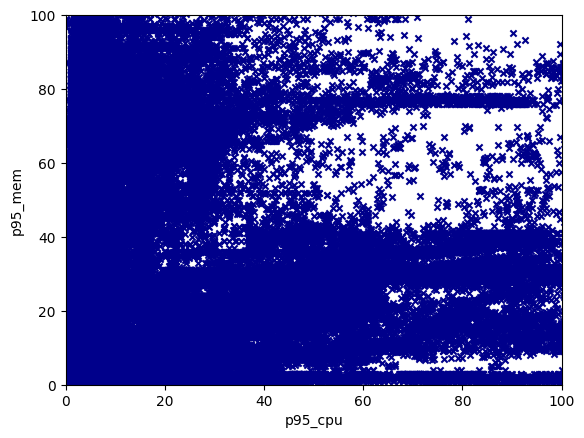

In [145]:
ax1 = df_result.plot.scatter(x='p95_cpu', y='p95_mem', c='DarkBlue', marker="x", xlim=[0, 100], ylim=[0, 100])

In [146]:
df_cost_sum = df_result[['date_key', 'ec2_cost', 'p95_cpu', 'p95_mem']]
df_cost_sum = df_cost_sum[~df_cost_sum['p95_cpu'].isna()]
df_cost_sum = df_cost_sum[~df_cost_sum['p95_mem'].isna()]

df_cost_sum.groupby('date_key').apply(lambda x: np.average(x['p95_cpu'], weights=x['ec2_cost'])).mean()

7.915980544940323

In [147]:
df_cost_sum.groupby('date_key').apply(lambda x: np.average(x['p95_mem'], weights=x['ec2_cost'])).mean()

12.818753843406176

In [148]:
df_utilization_summary = df_result[['resource_type','deployment_name', 'request_cpu', 'request_memory', 'p95_cpu' ,'p95_mem']].groupby(by=['resource_type','deployment_name', 'request_cpu', 'request_memory']).mean().reset_index()
df_utilization_summary.columns = ['resource_type','Deployment Name', 'Request CPU', 'Request Memory', 'Average CPU Utilization (%) at p95 level', 'Average Memory utilization (%) at p95 level']
df_utilization_summary

,resource_type,Deployment Name,Request CPU,Request Memory,Average CPU Utilization (%) at p95 level,Average Memory utilization (%) at p95 level
0,daemonset,aws-node,0.025,67108864.000,16.093,208.467
1,daemonset,aws-node,0.025,268435456.000,19.122,66.912
2,daemonset,dataplane-test-ds,0.010,67108864.000,0.000,5.000
3,daemonset,dataplane-test-ds,0.030,224395264.000,7.000,20.250
4,daemonset,dataplane-test-ds,0.072,429916160.000,6.374,22.140
...,...,...,...,...,...,...
500,statefulset,testing-statefulset43,0.100,1073741824.000,0.000,0.000
501,statefulset,testing-statefulset49,0.100,1073741824.000,0.000,0.000
502,statefulset,testing-statefulset55,0.100,1073741824.000,0.000,0.000
503,statefulset,testing-statefulset68,0.100,1073741824.000,0.000,0.000


In [149]:
# We want to aggregate daily ec2_cost and saving_opportunity by sum. In order to execute this aggregation,
# 1. Select 'date_key', 'k8s_namespace', 'deployment_name', 'ec2_cost', 'saving_opportunity' columns
# 2. Group by 'date_key', 'k8s_namespace', 'deployment_name' with sum aggregation at deployment level.
# 3. Reset the index

df_dailysaving_by_name = df_result[['date_key',  'resource_type', 'deployment_name', 'ec2_cost', 'saving_opportunity']].groupby(by=['date_key',  'resource_type','deployment_name']).sum().sort_values(by=['date_key','resource_type', 'deployment_name']).reset_index()
df_dailysaving_by_name['yearly_saving'] = df_dailysaving_by_name.apply(lambda x: x['saving_opportunity'] * 365.0, axis=1)
df_dailysaving_by_name.columns = ['Date',  'Resource type', 'Name', 'Daily EC2 cost', 'Daily cost saving opportunity (USD)', 'Yearly saving opportunity estimate (USD, daily saving opportunity * 365)']
df_dailysaving_by_name

,Date,Resource type,Name,Daily EC2 cost,Daily cost saving opportunity (USD),"Yearly saving opportunity estimate (USD, daily saving opportunity * 365)"
0,20250501,daemonset,aws-node,648.803,118.058,43090.988
1,20250501,daemonset,dataplane-test-ds,2428.228,1017.662,371446.757
2,20250501,daemonset,ebs-csi-node,6226.038,3111.869,1135832.063
3,20250501,daemonset,efs-csi-node,1550.827,688.715,251380.932
4,20250501,daemonset,eks-node-monitoring-agent,0.096,0.000,0.000
...,...,...,...,...,...,...
1689,20250531,replicaset,vertical-pod-autoscaler-recommender,141.819,64.658,23600.226
1690,20250531,replicaset,vertical-pod-autoscaler-updater,144.598,65.160,23783.266
1691,20250531,replicaset,vpa-generator,0.024,0.011,4.143
1692,20250531,statefulset,cloudwatch-logexport,174.263,68.395,24964.306


In [150]:
df_daily_sum = df_dailysaving_by_name[['Date', 'Daily EC2 cost', 'Daily cost saving opportunity (USD)']].groupby(by='Date').sum().reset_index()
df_daily_sum[['Daily EC2 cost', 'Daily cost saving opportunity (USD)']].mean()

Daily EC2 cost                        26792.355
Daily cost saving opportunity (USD)   11882.997
dtype: float64

In [151]:
df_dailysaving_total_by_namespace = df_result[['date_key',  'ec2_cost', 'saving_opportunity']].groupby(by=['date_key', ]).sum().reset_index()
df_dailysaving_total_by_namespace.columns = ['Date',  'Total daily EC2 cost (USD)', 'Total daily cost saving opportunity (USD)']
df_dailysaving_total_by_namespace

,Date,Total daily EC2 cost (USD),Total daily cost saving opportunity (USD)
0,20250501,26528.819,11738.667
1,20250502,26603.889,11775.953
2,20250503,26457.948,11762.057
3,20250504,26401.760,11767.029
4,20250505,27193.840,12051.958
5,20250506,28155.108,12451.326
6,20250507,27247.629,12012.661
7,20250508,27459.402,12118.395
8,20250509,27240.089,12056.626
9,20250510,27514.902,12235.777


## Export data

In [152]:
# Export dataframe to csv files
df_utilization_summary.to_csv('./hce-costanalysis-utilization-summary-aug01_aug31_all_env.csv', index=False)
df_dailysaving_by_name.to_csv('./hce-costanalysis-cost-saving-aug01_aug31_all_env.csv', index=False)
df_dailysaving_total_by_namespace.to_csv('./hce-costanalysis-total-saving-namespace-aug01_aug31_all_env.csv', index=False)

In [153]:
withcost_hce[withcost_hce['deployment_name'] == 'ebs-csi-controller']

,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name,p99_cpu,p95_cpu,p99_mem,p95_mem,request_cpu,request_memory,saving_opportunity
54,20250501,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,kube-system,ebs-csi-controller-6fcc4b4684,0.442,replicaset,ebs-csi-controller-6fcc4b4684,ebs-csi-controller,1.000,1.000,8.000,8.000,0.700,1879048192.000,0.215
79,20250501,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-restricted1,kube-system,ebs-csi-controller-84f895b6c5,0.462,replicaset,ebs-csi-controller-84f895b6c5,ebs-csi-controller,1.000,1.000,8.000,8.000,0.700,1879048192.000,0.225
104,20250501,aws.aws-dev2-uswest2.ast,aws-dev2-uswest2,ast,dev,sam,sam-processing1,kube-system,ebs-csi-controller-586bb65768,0.430,replicaset,ebs-csi-controller-586bb65768,ebs-csi-controller,1.420,1.000,7.000,7.000,0.700,1879048192.000,0.209
146,20250501,aws.aws-dev2-uswest2.cdp1,aws-dev2-uswest2,cdp1,dev,sam,sam-processing1,kube-system,ebs-csi-controller-788ddc988b,0.450,replicaset,ebs-csi-controller-788ddc988b,ebs-csi-controller,1.000,1.000,6.000,6.000,0.700,1879048192.000,0.218
161,20250501,aws.aws-dev2-uswest2.controltelemetry,aws-dev2-uswest2,controltelemetry,dev,sam,sam-processing1,kube-system,ebs-csi-controller-6778fb9977,0.349,replicaset,ebs-csi-controller-6778fb9977,ebs-csi-controller,1.000,1.000,12.000,11.793,0.700,939524096.000,0.169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
782142,20250531,aws.test1-uswest2.seas1,test1-uswest2,seas1,test,sam,sam-processing1,kube-system,ebs-csi-controller-c4677d97c,0.329,replicaset,ebs-csi-controller-c4677d97c,ebs-csi-controller,1.913,1.529,14.942,14.699,0.700,939524096.000,0.157
782159,20250531,aws.test1-uswest2.security,test1-uswest2,security,test,sam,sam-mgmt-truth1,kube-system,ebs-csi-controller-5c6c99797d,0.453,replicaset,ebs-csi-controller-5c6c99797d,ebs-csi-controller,1.000,1.000,6.000,5.977,0.700,1879048192.000,0.220
782187,20250531,aws.test1-uswest2.tableau,test1-uswest2,tableau,test,sam,sam-processing1,kube-system,ebs-csi-controller-7655bdb988,0.226,replicaset,ebs-csi-controller-7655bdb988,ebs-csi-controller,1.000,1.000,6.000,6.000,0.700,1879048192.000,0.110
782215,20250531,aws.test1-uswest2.tableau,test1-uswest2,tableau,test,sam,sam-processing2,kube-system,ebs-csi-controller-5dd8698cc6,0.329,replicaset,ebs-csi-controller-5dd8698cc6,ebs-csi-controller,1.000,1.000,11.000,11.000,0.700,939524096.000,0.160


In [154]:
only_ebscsicontroller= withcost_hce[withcost_hce['deployment_name'] == 'ebs-csi-controller'][['date_key','deployment_name', 'ec2_cost']].groupby(by=['date_key', 'deployment_name']).sum()

In [155]:
only_ebscsicontroller.to_csv('ebs-csi-controller_daily_aug01_aug31_all_env.csv')